In [ ]:
!pip install eurocropsml -q

In [ ]:
# Creamos una carpeta para mantener el espacio de trabajo limpio
!mkdir -p eurocrops_ml

# Descargamos únicamente el archivo preprocesado (1.5 GB)
!wget https://zenodo.org/records/15095445/files/preprocess.zip?download=1 -O eurocrops_ml/preprocess.zip

In [4]:
import zipfile
import os

zip_path = 'eurocrops_ml/preprocess.zip'
extract_path = 'eurocrops_ml/extracted_data'

print("Descomprimiendo archivos... Esto puede tomar un par de minutos.")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"¡Listo! Archivos extraídos en: {extract_path}")
# Eliminamos el .zip para no saturar el almacenamiento del Studio de Lightning AI
os.remove(zip_path)
print("Archivo .zip eliminado para liberar espacio en disco.")

Descomprimiendo archivos... Esto puede tomar un par de minutos.
¡Listo! Archivos extraídos en: eurocrops_ml/extracted_data
Archivo .zip eliminado para liberar espacio en disco.


In [5]:
import numpy as np
import os

extract_path = 'eurocrops_ml/extracted_data/preprocess'
# Listar los primeros 3 archivos de la carpeta
files = os.listdir(extract_path)
print(f"Total de archivos extraídos: {len(files)}")
print(f"Ejemplos de nombres de archivo:\n{files[:3]}\n")

# Cargar el primer archivo de la lista
sample_file_path = os.path.join(extract_path, files[0])
sample_data = np.load(sample_file_path, allow_pickle=True)

# Ver qué llaves (arrays) tiene guardadas este archivo .npz
print("Estructura interna del archivo .npz:")
for key in sample_data.files:
    print(f"- {key}: formato {sample_data[key].shape if hasattr(sample_data[key], 'shape') else type(sample_data[key])}")

Total de archivos extraídos: 706683
Ejemplos de nombres de archivo:
['LV008_12908108_3302000000.npz', 'LV005_12602821_3302000000.npz', 'LV005_12319874_3301010801.npz']

Estructura interna del archivo .npz:
- data: formato (45, 13)
- dates: formato (45,)
- center: formato (2,)


In [6]:
import os
import pandas as pd
from collections import Counter
from tqdm import tqdm

extract_path = 'eurocrops_ml/extracted_data/preprocess'
files = os.listdir(extract_path)

# Vamos a analizar una muestra de 50,000 parcelas para ver la distribución de códigos de cultivo
# Esto evitará saturar la memoria y nos dará una respuesta rápida.
sample_size = min(50000, len(files))
crop_codes = []

print(f"Analizando una muestra de {sample_size} archivos para identificar los códigos de cultivo...")
for file_name in tqdm(files[:sample_size]):
    if file_name.endswith('.npz'):
        # El código HCAT es la última parte antes de '.npz'
        parts = file_name.replace('.npz', '').split('_')
        if len(parts) == 3:
            crop_code = parts[2]
            crop_codes.append(crop_code)

# Contar la frecuencia de cada código
code_counts = Counter(crop_codes)
df_codes = pd.DataFrame(code_counts.items(), columns=['Código_HCAT', 'Frecuencia']).sort_values(by='Frecuencia', ascending=False)

print("\nLos 15 códigos de cultivo más comunes en la muestra:")
print(df_codes.head(15).to_string(index=False))

Analizando una muestra de 50000 archivos para identificar los códigos de cultivo...


100%|██████████| 50000/50000 [00:00<00:00, 1321939.97it/s]


Los 15 códigos de cultivo más comunes en la muestra:
Código_HCAT  Frecuencia
 3302000000       22376
 3301010101        4545
 3301010500        2217
 3399000000        2124
 3301010102        1893
 3301010402        1632
 3301990000        1465
 3301110000        1446
 3303050000        1338
 3301060401        1271
 3301090300         957
 3301090303         942
 3301030000         900
 3301010300         558
 3301020600         493


In [7]:
import os
import numpy as np
from tqdm import tqdm

extract_path = 'eurocrops_ml/extracted_data/preprocess'
files = os.listdir(extract_path)

maize_files = []
non_maize_files = []

print("Clasificando rutas de archivos...")
for file_name in files:
    if file_name.endswith('.npz'):
        parts = file_name.replace('.npz', '').split('_')
        if len(parts) == 3:
            code = parts[2]
            # Si empieza con el prefijo de maíz
            if code.startswith('330102'):
                maize_files.append(file_name)
            else:
                non_maize_files.append(file_name)

print(f"Encontrados: {len(maize_files)} archivos de Maíz.")

# Para evitar desbalance masivo, tomamos la misma cantidad de "No Maíz" aleatoriamente
np.random.seed(42)
selected_non_maize = np.random.choice(non_maize_files, size=len(maize_files), replace=False)

# Unimos la lista final de trabajo
dataset_files = maize_files + list(selected_non_maize)
np.random.shuffle(dataset_files) # Mezclamos para el entrenamiento

print(f"Dataset balanceado creado. Total de parcelas a procesar: {len(dataset_files)}")

Clasificando rutas de archivos...
Encontrados: 13632 archivos de Maíz.
Dataset balanceado creado. Total de parcelas a procesar: 27264


In [8]:
X_list = []
y_list = []

print("Cargando y procesando features (Series Temporales)...")
for file_name in tqdm(dataset_files):
    file_path = os.path.join(extract_path, file_name)
    try:
        payload = np.load(file_path, allow_pickle=True)
        data = payload['data'] # Matriz (45, 13)
        
        # Opcional: Para el modelo tradicional, vamos a extraer una sola banda o calcular NDVI.
        # Calculemos el perfil temporal de la banda Infrarroja Cercana (B8 -> índice 7) 
        # y la banda Roja (B4 -> índice 3) para construir el NDVI a lo largo del año.
        b8 = data[:, 7]
        b4 = data[:, 3]
        
        # Evitar división por cero sumando un pequeño épsilon
        ndvi = (b8 - b4) / (b8 + b4 + 1e-8) 
        
        # Si la serie no tiene exactamente 45 pasos (por variaciones), la truncamos o rellenamos
        # EuroCropsML suele venir estandarizado a 45 observaciones anuales.
        if len(ndvi) == 45:
            X_list.append(ndvi)
            # Definir etiqueta: 1 si es maíz, 0 si no lo es
            label = 1 if file_name.split('_')[2].startswith('330102') else 0
            y_list.append(label)
    except Exception as e:
        # Saltar archivos corruptos si los hay
        continue

X = np.array(X_list)
y = np.array(y_list)

print(f"\nMatrices listas.")
print(f"Dimensión de X (Parcelas, Pasos de tiempo de NDVI): {X.shape}")
print(f"Dimensión de y (Etiquetas): {y.shape}")

Cargando y procesando features (Series Temporales)...


100%|██████████| 27264/27264 [00:10<00:00, 2499.05it/s]


Matrices listas.
Dimensión de X (Parcelas, Pasos de tiempo de NDVI): (2025, 45)
Dimensión de y (Etiquetas): (2025,)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# 1. Separar datos en entrenamiento (80%) y prueba (20%)
# Usamos stratify=y para asegurar que ambos sets mantengan exactamente la misma proporción de maíz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de evaluación: {X_test.shape[0]}")

# 2. Configurar y entrenar el clasificador Random Forest
# Usamos 150 árboles para darle buena capacidad de generalización
model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred = model.predict(X_test)

# 4. Mostrar métricas de evaluación detalladas
print("\n================ REPORTE DE CLASIFICACIÓN ================")
print(classification_report(y_test, y_pred, target_names=['No Maíz (0)', 'Maíz (1)']))

print("================ MATRIZ DE CONFUSIÓN ================")
cm = confusion_matrix(y_test, y_pred)
print(f"Verdaderos Negativos (No Maíz correcto): {cm[0,0]}")
print(f"Falsos Positivos (No Maíz confundido con Maíz): {cm[0,1]}")
print(f"Falsos Negativos (Maíz confundido con No Maíz): {cm[1,0]}")
print(f"Verdaderos Positivos (Maíz correcto): {cm[1,1]}")
print(f"\nExactitud Total (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

Muestras de entrenamiento: 1620
Muestras de evaluación: 405

================ REPORTE DE CLASIFICACIÓN ================
              precision    recall  f1-score   support

 No Maíz (0)       0.84      0.79      0.82       204
    Maíz (1)       0.80      0.85      0.83       201

    accuracy                           0.82       405
   macro avg       0.82      0.82      0.82       405
weighted avg       0.82      0.82      0.82       405

================ MATRIZ DE CONFUSIÓN ================
Verdaderos Negativos (No Maíz correcto): 162
Falsos Positivos (No Maíz confundido con Maíz): 42
Falsos Negativos (Maíz confundido con No Maíz): 30
Verdaderos Positivos (Maíz correcto): 171

Exactitud Total (Accuracy): 0.8222


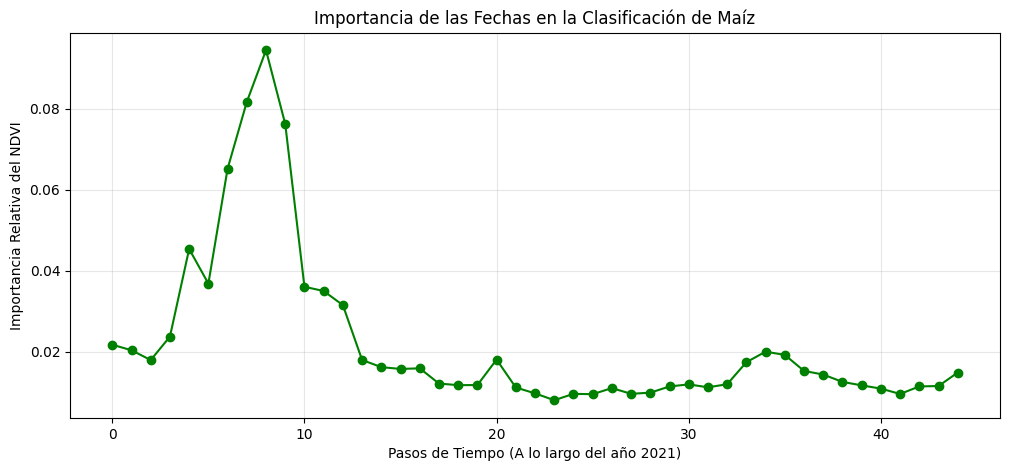

In [10]:
import pandas as pd

# Extraer la importancia de cada uno de los 45 pasos de tiempo
importances = model.feature_importances_

plt.figure(figsize=(12, 5))
plt.plot(importances, marker='o', color='green', linestyle='-')
plt.title('Importancia de las Fechas en la Clasificación de Maíz')
plt.xlabel('Pasos de Tiempo (A lo largo del año 2021)')
plt.ylabel('Importancia Relativa del NDVI')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
import joblib

# Definir el nombre del archivo de salida
model_filename = "random_forest_maiz_v1.pkl"

# Guardar el modelo entrenado
joblib.dump(model, model_filename)

print(f"¡Modelo guardado con éxito como '{model_filename}'!")

¡Modelo guardado con éxito como 'random_forest_maiz_v1.pkl'!


In [12]:
# En lugar de usar todo X, recortamos solo las columnas de alta importancia (ej. de la 4 a la 12)
X_recortado = X[:, 4:13] 

print(f"Nueva dimensión de X optimizado: {X_recortado.shape}")
# Salida esperada: (2025, 9) -> ¡Mucho más ligero!

# Ahora entrenas el nuevo Random Forest con esta matriz pequeña
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X_recortado, y, test_size=0.20, random_state=42, stratify=y)

model_corto = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
model_corto.fit(X_train, y_train)

# Guardas este nuevo snapshot especializado
import joblib
joblib.dump(model_corto, "rf_maiz_comayagua_optimizado.pkl")

Nueva dimensión de X optimizado: (2025, 9)


['rf_maiz_comayagua_optimizado.pkl']

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib

# 1. Recortar la matriz X a la ventana crítica (Pasos del 4 al 12 inclusive -> 9 características)
X_corto = X[:, 2:13]

# 2. División estratificada (80% entrenamiento, 20% evaluación)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_corto, y, test_size=0.20, random_state=42, stratify=y
)

print(f"--- Configuración del Modelo Corto ---")
print(f"Dimensiones de X_train (Muestras, Características): {X_train_c.shape}")
print(f"Dimensiones de X_test  (Muestras, Características): {X_test_c.shape}\n")

# 3. Entrenar el nuevo clasificador optimizado
model_corto = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
model_corto.fit(X_train_c, y_train_c)

# 4. Predicciones
y_pred_c = model_corto.predict(X_test_c)

# 5. Despliegue de Métricas
print("================ REPORTE DE CLASIFICACIÓN (MODELO CORTO) ================")
print(classification_report(y_test_c, y_pred_c, target_names=['No Maíz (0)', 'Maíz (1)']))

print("================ MATRIZ DE CONFUSIÓN ================")
cm_c = confusion_matrix(y_test_c, y_pred_c)
print(f"Verdaderos Negativos (No Maíz correcto): {cm_c[0,0]}")
print(f"Falsos Positivos (No Maíz confundido con Maíz): {cm_c[0,1]}")
print(f"Falsos Negativos (Maíz confundido con No Maíz): {cm_c[1,0]}")
print(f"Verdaderos Positivos (Maíz correcto): {cm_c[1,1]}")

acc_corto = accuracy_score(y_test_c, y_pred_c)
print(f"\nExactitud Total (Accuracy) del Modelo Corto: {acc_corto:.4f}")


--- Configuración del Modelo Corto ---
Dimensiones de X_train (Muestras, Características): (1620, 11)
Dimensiones de X_test  (Muestras, Características): (405, 11)

================ REPORTE DE CLASIFICACIÓN (MODELO CORTO) ================
              precision    recall  f1-score   support

 No Maíz (0)       0.87      0.76      0.81       204
    Maíz (1)       0.79      0.88      0.83       201

    accuracy                           0.82       405
   macro avg       0.83      0.82      0.82       405
weighted avg       0.83      0.82      0.82       405

================ MATRIZ DE CONFUSIÓN ================
Verdaderos Negativos (No Maíz correcto): 156
Falsos Positivos (No Maíz confundido con Maíz): 48
Falsos Negativos (Maíz confundido con No Maíz): 24
Verdaderos Positivos (Maíz correcto): 177

Exactitud Total (Accuracy) del Modelo Corto: 0.8222


In [16]:
import os
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

extract_path = 'eurocrops_ml/extracted_data/preprocess'
files = os.listdir(extract_path)

maize_files = []
non_maize_files = []

# 1. Escaneo completo de los 700k archivos
print("Escaneando el universo completo de parcelas...")
for file_name in files:
    if file_name.endswith('.npz'):
        parts = file_name.replace('.npz', '').split('_')
        if len(parts) == 3:
            code = parts[2]
            if code.startswith('330102'):
                maize_files.append(file_name)
            else:
                non_maize_files.append(file_name)

print(f"Total disponible en el dataset -> Maíz: {len(maize_files)} | No Maíz: {len(non_maize_files)}")

# 2. Definir un nuevo límite más alto y balancear
# Tomaremos todas las de maíz que podamos procesar de forma segura (ej. hasta 15,000 o el máximo disponible)
max_samples = min(15000, len(maize_files)) 

np.random.seed(42)
selected_maize = np.random.choice(maize_files, size=max_samples, replace=False)
selected_non_maize = np.random.choice(non_maize_files, size=max_samples, replace=False)

expanded_files = list(selected_maize) + list(selected_non_maize)
np.random.shuffle(expanded_files)

print(f"Extrayendo series temporales para {len(expanded_files)} parcelas balanceadas...")

# 3. Extracción de la ventana corta (Pasos 4 al 12)
X_expanded_list = []
y_expanded_list = []

for file_name in tqdm(expanded_files):
    file_path = os.path.join(extract_path, file_name)
    try:
        payload = np.load(file_path, allow_pickle=True)
        data = payload['data']
        
        # NDVI de la ventana crítica
        b8 = data[4:13, 7]
        b4 = data[4:13, 3]
        ndvi_corto = (b8 - b4) / (b8 + b4 + 1e-8)
        
        if len(ndvi_corto) == 9:
            X_expanded_list.append(ndvi_corto)
            label = 1 if file_name.split('_')[2].startswith('330102') else 0
            y_expanded_list.append(label)
    except:
        continue

X_expanded = np.array(X_expanded_list)
y_expanded = np.array(y_expanded_list)

print(f"\nNuevo dataset listo. Dimensión de X: {X_expanded.shape}")

Escaneando el universo completo de parcelas...
Total disponible en el dataset -> Maíz: 13632 | No Maíz: 693051
Extrayendo series temporales para 27264 parcelas balanceadas...


100%|██████████| 27264/27264 [00:08<00:00, 3327.79it/s]



Nuevo dataset listo. Dimensión de X: (27257, 9)


In [17]:
# 4. División de los nuevos datos expandidos
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_expanded, y_expanded, test_size=0.20, random_state=42, stratify=y_expanded
)

# Incrementar árboles a 250 para aprovechar el volumen de datos sin perder velocidad
model_expandido = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)

print("Entrenando el modelo expandido...")
model_expandido.fit(X_train_e, y_train_e)

# 5. Evaluación
y_pred_e = model_expandido.predict(X_test_e)

print("\n================ REPORTE DE CLASIFICACIÓN (MODELO EXPANDIDO) ================")
print(classification_report(y_test_e, y_pred_e, target_names=['No Maíz (0)', 'Maíz (1)']))
print(f"Exactitud Total (Accuracy): {accuracy_score(y_test_e, y_pred_e):.4f}")

# Guardar si los resultados mejoraron
# import joblib
# joblib.dump(model_expandido, "rf_maiz_comayagua_expandido.pkl")
# print("\nSnapshot guardado como 'rf_maiz_comayagua_expandido.pkl'")

Entrenando el modelo expandido...

================ REPORTE DE CLASIFICACIÓN (MODELO EXPANDIDO) ================
              precision    recall  f1-score   support

 No Maíz (0)       0.82      0.81      0.81      2726
    Maíz (1)       0.81      0.82      0.82      2726

    accuracy                           0.81      5452
   macro avg       0.81      0.81      0.81      5452
weighted avg       0.81      0.81      0.81      5452

Exactitud Total (Accuracy): 0.8138


In [ ]:
import os
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

extract_path = 'eurocrops_ml/extracted_data/preprocess'

# Reutilizamos la lista expanded_files creada en el paso anterior (las ~27k parcelas balanceadas)
X_combined_list = []
y_combined_list = []

print("Calculando EVI + NDRE para el dataset expandido...")

for file_name in tqdm(expanded_files):
    file_path = os.path.join(extract_path, file_name)
    try:
        payload = np.load(file_path, allow_pickle=True)
        data = payload['data'] # Matriz (45, 13)
        
        # 1. Extraer las bandas necesarias para la ventana crítica (pasos 4 al 12)
        b2 = data[4:13, 1]  # Azul
        b4 = data[4:13, 3]  # Rojo
        b5 = data[4:13, 4]  # Red Edge 1
        b8 = data[4:13, 7]  # NIR
        
        # 2. Calcular EVI (Multiplicamos por 10000 si los datos vinieran en reflectancia entera [0-10000], 
        # pero EuroCropsML viene en punto flotante [0-1], por lo que la constante +1 es correcta)
        denom_evi = b8 + 6.0 * b4 - 7.5 * b2 + 1.0
        # Evitar división por cero
        denom_evi = np.where(denom_evi == 0, 1e-8, denom_evi)
        evi_corto = 2.5 * ((b8 - b4) / denom_evi)
        
        # 3. Calcular NDRE
        denom_ndre = b8 + b5 + 1e-8
        ndre_corto = (b8 - b5) / denom_ndre
        
        # 4. Concatenar ambos índices horizontalmente (9 pasos de EVI + 9 pasos de NDRE = 18 features)
        features_combinadas = np.hstack((evi_corto, ndre_corto))
        
        if len(features_combinadas) == 18:
            X_combined_list.append(features_combinadas)
            label = 1 if file_name.split('_')[2].startswith('330102') else 0
            y_combined_list.append(label)
    except Exception as e:
        continue

X_combined = np.array(X_combined_list)
y_combined = np.array(y_combined_list)

print(f"\nDataset Multi-Índice listo.")
print(f"Dimensión final de X: {X_combined.shape} (Parcelas, 18 características espectrales)")

# ==================== ENTRENAMIENTO Y EVALUACIÓN ====================

# División estratificada (80% Train, 20% Test)
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_combined, y_combined, test_size=0.20, random_state=42, stratify=y_combined
)

# Entrenar clasificador con 250 árboles
model_combinado = RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1)
print("\nEntrenando Random Forest con EVI + NDRE...")
model_combinado.fit(X_train_cb, y_train_cb)

# Predicción y Métricas
y_pred_cb = model_combinado.predict(X_test_cb)

print("\n================ REPORTE DE CLASIFICACIÓN (EVI + NDRE) ================")
print(classification_report(y_test_cb, y_pred_cb, target_names=['No Maíz (0)', 'Maíz (1)']))

print("================ MATRIZ DE CONFUSIÓN ================")
cm_cb = confusion_matrix(y_test_cb, y_pred_cb)
print(f"Verdaderos Negativos: {cm_cb[0,0]} | Falsos Positivos: {cm_cb[0,1]}")
print(f"Falsos Negativos: {cm_cb[1,0]} | Verdaderos Positivos: {cm_cb[1,1]}")
print(f"\nExactitud Total (Accuracy): {accuracy_score(y_test_cb, y_pred_cb):.4f}")

# Guardar snapshot final para Comayagua
joblib.dump(model_combinado, "rf_maiz_comayagua_evi_ndre.pkl")
print("\n¡Snapshot guardado con éxito como 'rf_maiz_comayagua_evi_ndre.pkl'!")

Calculando EVI + NDRE para el dataset expandido...


100%|██████████| 27264/27264 [00:04<00:00, 6389.44it/s]



Dataset Multi-Índice listo.
Dimensión final de X: (27257, 18) (Parcelas, 18 características espectrales)

Entrenando Random Forest con EVI + NDRE...
